In [ ]:
import torch
import torch.nn as nn
import torch.quantization
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import os

print("Torch version:", torch.__version__)

Torch version: 2.6.0+cu124


In [ ]:
model_fp32 = models.resnet18(pretrained=True)
model_fp32.eval()

print("Pretrained ResNet18 (FP32) model loaded.")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


Pretrained ResNet18 (FP32) model loaded.


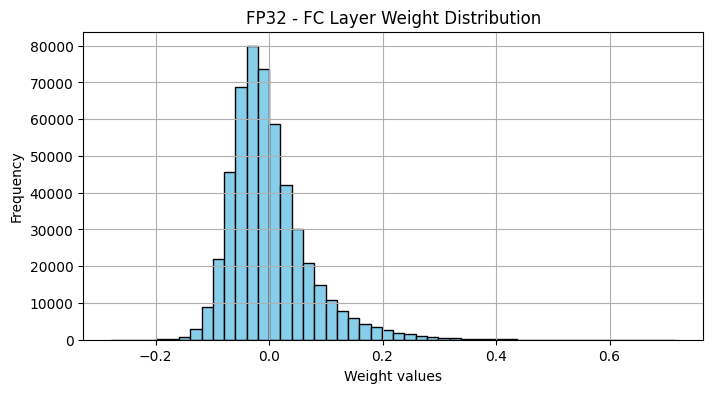

In [ ]:
fc_weights_fp32 = model_fp32.fc.weight.data.cpu().numpy().flatten()

plt.figure(figsize=(8, 4))
plt.hist(fc_weights_fp32, bins=50, color='skyblue', edgecolor='black')
plt.title("FP32 - FC Layer Weight Distribution")
plt.xlabel("Weight values")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [ ]:
quantized_model = torch.quantization.quantize_dynamic(model_fp32, {nn.Linear}, dtype=torch.qint8)
quantized_model.eval()

print("Dynamic quantization applied to the model.")

Dynamic quantization applied to the model.


In [ ]:
def get_model_size(model, filename="temp.p"):
    torch.save(model.state_dict(), filename)
    size = os.path.getsize(filename) / 1e6
    os.remove(filename)
    return size

fp32_size = get_model_size(model_fp32, "fp32_model.p")
quant_size = get_model_size(quantized_model, "quant_model.p")

print(f"FP32 Model Size: {fp32_size:.2f} MB")
print(f"Quantized Model Size: {quant_size:.2f} MB")

FP32 Model Size: 46.84 MB
Quantized Model Size: 45.30 MB


In [ ]:
dummy_input = torch.randn(1, 3, 224, 224)

with torch.no_grad():
    output_fp32 = model_fp32(dummy_input)
    output_quant = quantized_model(dummy_input)

print("Output from FP32 model (first 5 elements):", output_fp32[0][:5])
print("Output from Quantized model (first 5 elements):", output_quant[0][:5])

Output from FP32 model (first 5 elements): tensor([0.1193, 2.8964, 2.6209, 2.8624, 4.4099])
Output from Quantized model (first 5 elements): tensor([0.1397, 2.8880, 2.6465, 2.8845, 4.4650])


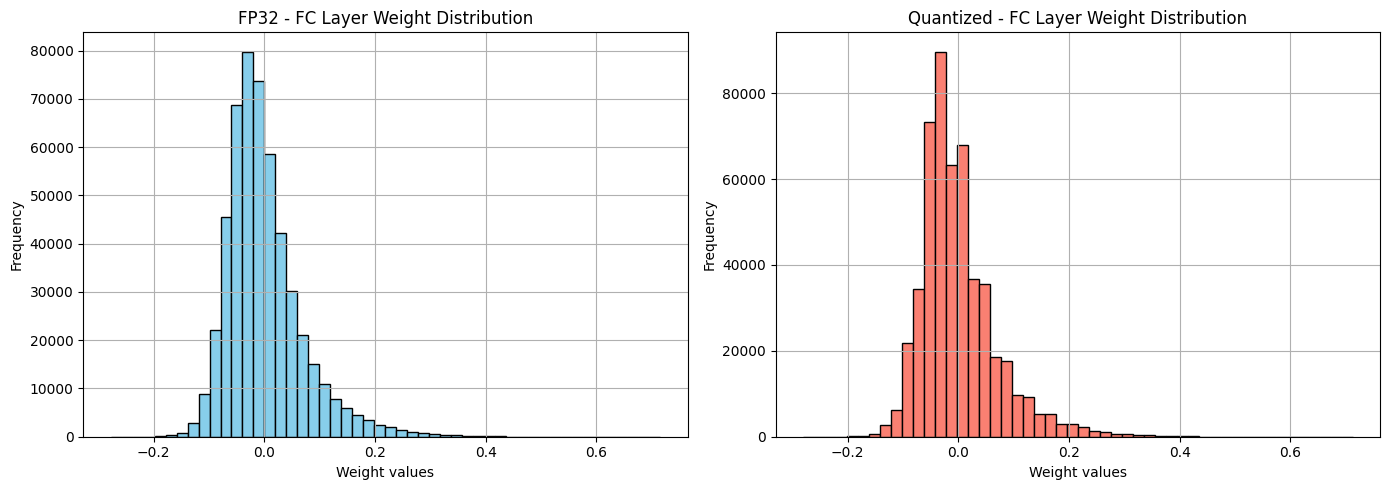

In [ ]:
if hasattr(quantized_model.fc, 'weight'):
    fc_weights_quant = quantized_model.fc.weight().dequantize().cpu().numpy().flatten()
else:
    fc_weights_quant = quantized_model.fc._packed_params._packed_weight.dequantize().cpu().numpy().flatten()

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(fc_weights_fp32, bins=50, color='skyblue', edgecolor='black')
plt.title("FP32 - FC Layer Weight Distribution")
plt.xlabel("Weight values")
plt.ylabel("Frequency")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(fc_weights_quant, bins=50, color='salmon', edgecolor='black')
plt.title("Quantized - FC Layer Weight Distribution")
plt.xlabel("Weight values")
plt.ylabel("Frequency")
plt.grid(True)

plt.tight_layout()
plt.show()